# 07 — Baseline (Control): HRP-CVaR + 12m momentum filter

Monthly walk-forward rebalance, **2019-01 → 2024-12**. No macro overlay — this is the control group the LLM (Track A) and MC-Nash (Track B) must beat.

**Weight logic** (no lookahead, enforced by the orchestrator — each rebalance fn only sees data strictly before the rebalance date):

```
mom = price[t] / price[t - 252d] - 1
eligible = [s for s in assets if mom[s] > 0]
if   none eligible  → 100% BIL
elif one eligible   → 100% that asset
else                → HRP-CVaR(returns[eligible])
```

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Setup

In [2]:
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END   = "2024-12-31"
LOOKBACK_DAYS = 756  # 3y for HRP estimation

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
BENCHMARK = "SPY"

# Pull enough history for the 3y lookback before SIM_START + the 252d momentum window
prices = mf.get_prices(SYMBOLS + [BENCHMARK], start="2014-01-01", end=SIM_END)
rebalance_dates = mf.monthly_rebalance_dates(prices, start=SIM_START, end=SIM_END)
print(f"{len(rebalance_dates)} monthly rebalances  {rebalance_dates[0].date()} → {rebalance_dates[-1].date()}")

72 monthly rebalances  2019-01-02 → 2024-12-02


## 2. Build target weights via the walk-forward orchestrator

In [3]:
def baseline_fn(ctx):
    return mf.hrp_momentum_weights(ctx["returns"], ctx["prices"])

targets = mf.build_walk_forward_targets(
    prices[SYMBOLS],
    rebalance_dates=rebalance_dates,
    weight_fns={"baseline": baseline_fn},
    lookback_days=LOOKBACK_DAYS,
)
tgt = targets["baseline"]
print(f"target weights: {tgt.shape}, non-NaN rows: {tgt.dropna(how='all').shape[0]}")

target weights: (2787, 4), non-NaN rows: 72


In [4]:
tgt.loc[rebalance_dates].dropna(how="all").round(3)

symbol,SWDA.L,XLK,IAU,BIL
2019-01-02,0.000,0.000,0.000,1.000
2019-02-01,0.037,0.000,0.000,0.963
2019-03-01,0.024,0.016,0.000,0.960
2019-04-01,0.025,0.016,0.000,0.959
2019-05-01,0.026,0.017,0.000,0.957
...,...,...,...,...
2024-08-01,0.086,0.047,0.083,0.785
2024-09-02,0.088,0.047,0.086,0.779
2024-10-01,0.088,0.047,0.087,0.778
2024-11-01,0.091,0.048,0.089,0.772


## 3. Simulate

In [5]:
pf       = mf.run_rebalance_sim(prices[SYMBOLS], tgt, init_cash=INIT_CASH)
spy_bh   = mf.single_asset_buy_and_hold(prices[BENCHMARK].loc[SIM_START:SIM_END], init_cash=INIT_CASH)
ew_bh    = mf.buy_and_hold(prices[SYMBOLS].loc[SIM_START:SIM_END], dict(zip(SYMBOLS, [0.25] * 4)), init_cash=INIT_CASH)

def row(p):
    return {
        "total_return":      float(p.total_return()),
        "annualized_return": float(p.annualized_return()),
        "annualized_vol":    float(p.annualized_volatility()),
        "sharpe":            float(p.sharpe_ratio()),
        "sortino":           float(p.sortino_ratio()),
        "calmar":            float(p.calmar_ratio()),
        "max_drawdown":      float(p.max_drawdown()),
    }

stats = pd.DataFrame({"Baseline (HRP+mom)": row(pf), "EW B&H": row(ew_bh), f"{BENCHMARK} B&H": row(spy_bh)})
stats.round(4)

,Baseline (HRP+mom),EW B&H,SPY B&H
total_return,0.0373,1.2430,1.3426
annualized_return,0.0049,0.2206,0.2285
annualized_vol,0.0696,0.1489,0.2395
sharpe,0.1055,1.4140,0.9798
sortino,0.1429,2.0249,1.3680
calmar,0.0278,1.2280,0.6699
max_drawdown,-0.1774,-0.1797,-0.3410


## 4. Crisis window diagnostic (2022)

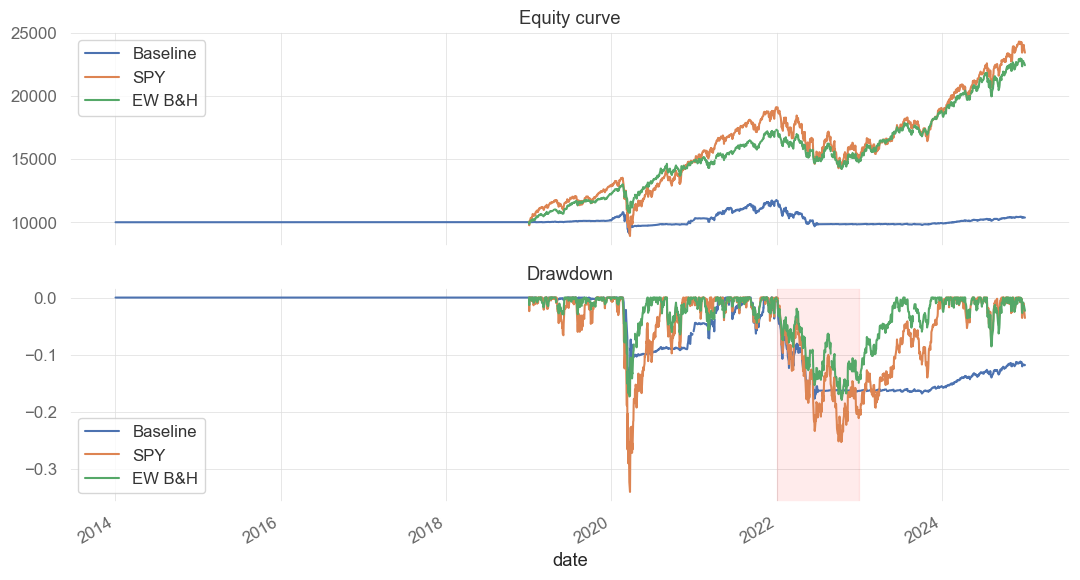

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
pd.DataFrame({"Baseline": pf.value(), f"{BENCHMARK}": spy_bh.value(), "EW B&H": ew_bh.value()}).plot(ax=axes[0], grid=True, title="Equity curve")
pd.DataFrame({"Baseline": pf.drawdown(), f"{BENCHMARK}": spy_bh.drawdown(), "EW B&H": ew_bh.drawdown()}).plot(ax=axes[1], grid=True, title="Drawdown")
axes[1].axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="red", alpha=0.08)
fig.tight_layout();

## 5. Persist

In [7]:
out_targets = Path.cwd().parent / "data" / "baseline_targets_2019_2024.parquet"
out_equity  = Path.cwd().parent / "data" / "baseline_equity_2019_2024.parquet"
tgt.to_parquet(out_targets)
pf.value().to_frame("value").to_parquet(out_equity)
print(f"wrote {out_targets.name} and {out_equity.name}")

wrote baseline_targets_2019_2024.parquet and baseline_equity_2019_2024.parquet
